<a href="https://colab.research.google.com/github/harshrajmishra422/ESP32_OTA_updates_harsh/blob/main/digital-inverter-openlane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital inverter with OpenLane

```
Copyright 2022 Google LLC.
SPDX-License-Identifier: Apache-2.0
```

Run a simple digital inverter design thru the [OpenLane](https://github.com/The-OpenROAD-Project/OpenLane/) GDS to RTL flow targeting the [open source SKY130 PDK](https://github.com/google/skywater-pdk/).

In [102]:
#@title Install dependencies {display-mode: "form"}
#@markdown - Click the ▷ button to setup the digital design environment based on [conda-eda](https://github.com/hdl/conda-eda).

openlane_version = 'latest' #@param {type:"string"}
open_pdks_version = 'latest' #@param {type:"string"}

if openlane_version == 'latest':
  openlane_version = ''
if open_pdks_version == 'latest':
  open_pdks_version = ''

import os
import pathlib

!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xj bin/micromamba
conda_prefix_path = pathlib.Path('conda-env')
CONDA_PREFIX = str(conda_prefix_path.resolve())
!bin/micromamba create --yes --prefix $CONDA_PREFIX
!echo 'python ==3.7*' >> {CONDA_PREFIX}/conda-meta/pinned
!CI=0 bin/micromamba install --yes --prefix $CONDA_PREFIX \
                     --channel litex-hub \
                     --channel main \
                     openlane={openlane_version} \
                     open_pdks.sky130a={open_pdks_version}
!python -m pip install gdstk gdstk
PATH = os.environ['PATH']
%env CONDA_PREFIX={CONDA_PREFIX}
%env PATH={CONDA_PREFIX}/bin:{PATH}


Empty environment created at prefix: /content/conda-env
⚠ Shard Index for litex-hub/linux-64 not available, falling back to flat repodata
Using Flat Repodata for litex-hub/linux-64                                                ✔ Done (0.0 sec)
⚠ Shard Index for litex-hub/noarch not available, falling back to flat repodata
Using Flat Repodata for litex-hub/noarch                                                  ✔ Done (0.0 sec)
⚠ Shard Index for main/linux-64 not available, falling back to flat repodata
Using Flat Repodata for main/linux-64                                                     ✔ Done (1.3 sec)
⚠ Shard Index for main/noarch not available, falling back to flat repodata
Using Flat Repodata for main/noarch                                                       ✔ Done (0.0 sec)
Parsing Packages' Records                                                                 ✔ Done (1.3 sec)

Pinned packages:

  - python==3.7*

Resolving Environment                                     

In [103]:
!find /content/runs/RUN_2026.09.25_15.15.01/results -type f | sort

/content/runs/RUN_2026.09.25_15.15.01/results/cts/waste_bin_wakeup.def
/content/runs/RUN_2026.09.25_15.15.01/results/cts/waste_bin_wakeup.odb
/content/runs/RUN_2026.09.25_15.15.01/results/cts/waste_bin_wakeup.sdc
/content/runs/RUN_2026.09.25_15.15.01/results/final/def/waste_bin_wakeup.def
/content/runs/RUN_2026.09.25_15.15.01/results/final/lib/waste_bin_wakeup.lib
/content/runs/RUN_2026.09.25_15.15.01/results/final/sdc/waste_bin_wakeup.sdc
/content/runs/RUN_2026.09.25_15.15.01/results/final/sdf/waste_bin_wakeup.sdf
/content/runs/RUN_2026.09.25_15.15.01/results/final/verilog/gl/waste_bin_wakeup.nl.v
/content/runs/RUN_2026.09.25_15.15.01/results/final/verilog/gl/waste_bin_wakeup.v
/content/runs/RUN_2026.09.25_15.15.01/results/floorplan/waste_bin_wakeup.def
/content/runs/RUN_2026.09.25_15.15.01/results/floorplan/waste_bin_wakeup.odb
/content/runs/RUN_2026.09.25_15.15.01/results/placement/waste_bin_wakeup.def
/content/runs/RUN_2026.09.25_15.15.01/results/placement/waste_bin_wakeup.nl.v
/co

In [104]:
!flow.tcl -design .

OpenLane 2023.11.03_0_gf4f8dad8-conda
All rights reserved. (c) 2020-2022 Efabless Corporation and contributors.
Available under the Apache License, version 2.0. See the LICENSE file for more details.

[INFO]: Using configuration in 'config.json'...
[INFO]: PDK Root: /content/conda-env/share/pdk
[INFO]: Process Design Kit: sky130A
[INFO]: Standard Cell Library: sky130_fd_sc_hd
[INFO]: Optimization Standard Cell Library: sky130_fd_sc_hd
[WARNING]: DIODE_INSERTION_STRATEGY is now deprecated; use GRT_REPAIR_ANTENNAS, DIODE_ON_PORTS and RUN_HEURISTIC_DIODE_INSERTION instead.
[INFO]: DIODE_INSERTION_STRATEGY set to 3. Setting GRT_REPAIR_ANTENNAS to 1
[INFO]: Run Directory: /content/runs/RUN_2026.09.25_18.45.11
[INFO]: Saving runtime environment...
[INFO]: Preparing LEF files for the nom corner...
[INFO]: Preparing LEF files for the min corner...
[INFO]: Preparing LEF files for the max corner...
[WARNING]: PNR_SDC_FILE is not set. It is recommended to write a custom SDC file for the design. D

In [105]:
%env PDK=sky130A

env: PDK=sky130A


In [106]:
!sed -i '/"CLOCK_TREE_SYNTH": false,/d' /content/config.json
!cat /content/config.json

{
    "DESIGN_NAME": "waste_bin_wakeup",
    "VERILOG_FILES": "dir::waste_bin_wakeup.v",
    "CLOCK_PORT": null,
    "PL_RANDOM_GLB_PLACEMENT": false,
    "FP_SIZING": "absolute",
    "DIE_AREA": "0 0 70 70",
    "PL_TARGET_DENSITY": 0.75,
    "FP_PDN_AUTO_ADJUST": false,
    "FP_PDN_VPITCH": 25,
    "FP_PDN_HPITCH": 25,
    "FP_PDN_VOFFSET": 5,
    "FP_PDN_HOFFSET": 5,
    "DIODE_INSERTION_STRATEGY": 3
}


In [107]:
!ls -lh /content/runs/RUN_2026.09.25_15.15.01/logs/signoff/

total 40K
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-gdsii.errors
-rw-r--r-- 1 root root  16K Sep 25 17:31 1-gdsii.log
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-gdsii.warnings
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-gds_ptrs.errors
-rw-r--r-- 1 root root 2.7K Sep 25 17:31 1-gds_ptrs.log
-rw-r--r-- 1 root root   59 Sep 25 17:31 1-gds_ptrs.warnings
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-lef.errors
-rw-r--r-- 1 root root 9.6K Sep 25 17:31 1-lef.log
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-lef.warnings
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-maglef.errors
-rw-r--r-- 1 root root  796 Sep 25 17:31 1-maglef.log
-rw-r--r-- 1 root root    0 Sep 25 17:31 1-maglef.warnings


In [108]:
!grep -n "Stream Out GDS\|GDSII\|gds" /content/conda-env/share/openlane/flow.tcl | tail -20

133:        run_klayout_gds_xor
191:        "gds_magic" "run_magic_step" \
192:        "gds_klayout" "run_klayout_step" \
292:        {-gds required}
302:    set ::env(GDS_INPUT) [file normalize $arg_values(-gds)]
311:            $::env(OPENLANE_ROOT)/scripts/magic/gds/drc_batch.tcl \
317:            $::env(OPENLANE_ROOT)/scripts/magic/gds/drc_batch.tcl \
323:    # runs device level lvs on -gds/CURRENT_GDS and -net/CURRENT_NETLIST
324:    # extracts gds only if EXT_NETLIST does not exist
327:        {-gds optional}
335:    if { [info exists arg_values(-gds)] } {
336:        set ::env(CURRENT_GDS) [file normalize $arg_values(-gds)]
338:        set ::env(CURRENT_GDS) $::env(signoff_results)/$::env(DESIGN_NAME).gds
347:    set ::env(EXT_NETLIST) $::env(signoff_results)/$::env(DESIGN_NAME).gds.spice


In [109]:
!sed -n '180,210p' /content/conda-env/share/openlane/flow.tcl

    set ANTENNACHECK_ENABLED [expr ![info exists flags_map(-no_antennacheck)] ]

    set steps [dict create \
        "verilator_lint_check" "run_verilator_step" \
        "synthesis" "run_synthesis" \
        "floorplan" "run_floorplan" \
        "placement" "run_placement_step" \
        "cts" "run_cts_step" \
        "routing" "run_routing_step" \
        "parasitics_sta" "run_parasitics_sta_step" \
        "irdrop" "run_irdrop_report_step" \
        "gds_magic" "run_magic_step" \
        "gds_klayout" "run_klayout_step" \
        "lvs" "run_lvs_step $LVS_ENABLED " \
        "drc" "run_drc_step $DRC_ENABLED " \
        "antenna_check" "run_antenna_check_step $ANTENNACHECK_ENABLED "
    ]

    set ::env(CURRENT_STEP) "verilator_lint_check"

    set start_step $::env(CURRENT_STEP)
    set end_step "antenna_check"

    set failed 0;
    set exe 0;
    dict for {step_name step_exe} $steps {
        if { [ string equal $start_step $step_name ] } {
            set exe 1;
        }

      

In [110]:
!grep -n "proc run_magic_step" /content/conda-env/share/openlane/flow.tcl

122:proc run_magic_step {args} {


In [111]:
!sed -n '115,145p' /content/conda-env/share/openlane/flow.tcl


proc run_erc_step {args} {
    if { $::env(RUN_CVC) } {
        run_erc
    }
}

proc run_magic_step {args} {
    if {$::env(RUN_MAGIC)} {
        run_magic
    }
}

proc run_klayout_step {args} {
    if {$::env(RUN_KLAYOUT)} {
        run_klayout
    }
    if {$::env(RUN_KLAYOUT_XOR)} {
        run_klayout_gds_xor
    }
}

proc run_timing_check_step {args} {
    check_timing_violations\
        -quit_on_hold_vios [expr $::env(QUIT_ON_TIMING_VIOLATIONS) && $::env(QUIT_ON_HOLD_VIOLATIONS)]\
        -quit_on_setup_vios [expr $::env(QUIT_ON_TIMING_VIOLATIONS) && $::env(QUIT_ON_SETUP_VIOLATIONS)]
}

proc run_verilator_step {} {
    if { $::env(RUN_LINTER) } {
        run_verilator


In [112]:
!grep -n "proc run_magic " /content/conda-env/share/openlane/flow.tcl

In [113]:
!grep -Rni "proc run_magic" /content/conda-env/share/openlane/ | head -20

/content/conda-env/share/openlane/flow.tcl:122:proc run_magic_step {args} {
/content/conda-env/share/openlane/flow.tcl:286:proc run_magic_drc_batch {args} {
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:15:proc run_magic {args} {
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:93:proc run_magic_drc {args} {
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:133:proc run_magic_spice_export {args} {
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:210:proc run_magic_antenna_check {args} {
/content/conda-env/share/openlane/scripts/utils/utils.tcl:257:proc run_magic_script {args} {


In [114]:
!sed -n '1,92p' /content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl

# Copyright 2020-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

proc run_magic {args} {
    TIMER::timer_start
    increment_index
    puts_info "Running Magic to generate various views..."
    # |----------------------------------------------------|
    # |----------------   6. TAPE-OUT ---------------------|
    # |----------------------------------------------------|
    set log [index_file $::env(signoff_logs)/gdsii.log]
    puts_info "Streaming out GDSII with Magi

In [115]:
!sed -n '1,220p' /content/conda-env/share/openlane/scripts/magic/def/mag_gds.tcl

# Copyright 2020 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
drc off

source $::env(SCRIPTS_DIR)/magic/def/read.tcl

load $::env(DESIGN_NAME)
select top cell

# padding
if { $::env(MAGIC_PAD) } {
	puts "\[INFO\]: Padding LEFs"
	# assuming scalegrid 1 2
	# use um
	select top cell
	box grow right [expr 100*($::env(PLACE_SITE_WIDTH))]
	box grow left [expr 100*($::env(PLACE_SITE_WIDTH))]
	box grow up [expr 100*($::env(PLACE_SITE_HEIGHT))]
	box grow down [expr 100*($::env(PLAC

In [116]:
!sed -n '1,220p' /content/conda-env/share/openlane/scripts/magic/def/read.tcl

# Copyright 2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
lef read $::env(TECH_LEF)
if {  [info exist ::env(EXTRA_LEFS)] } {
    foreach lef_file $::env(EXTRA_LEFS) {
        lef read $lef_file
    }
}

set def_read_args [list]
lappend def_read_args $::env(CURRENT_DEF)
if { $::env(MAGIC_DEF_NO_BLOCKAGES) } {
    lappend def_read_args -noblockage
}
if { $::env(MAGIC_DEF_LABELS) } {
    lappend def_read_args -labels
}


def read {*}$def_read_args

In [117]:
!find /content/runs/RUN_2026.09.25_15.15.01 -name "sky130_fd_sc_hd*.tlef" -o -name "*.tlef" | head -20

In [118]:
!find /content -name "sky130_fd_sc_hd.tlef" -o -name "sky130A.tech.lef" 2>/dev/null | head -20

In [119]:
!echo "PDK_ROOT=$PDK_ROOT"
!echo "PDK=$PDK"
!echo "TECH_LEF=$TECH_LEF"

PDK_ROOT=
PDK=sky130A
TECH_LEF=


In [120]:
!find /content/conda-env -type f \( -name "*.tlef" -o -name "*.lef" \) 2>/dev/null | grep -E "sky130|fd_sc_hd" | head -30

/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/lef/sky130_fd_sc_hdll.lef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__min.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__max.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__rram__max.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__rram__min.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__nom.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hdll/techlef/sky130_fd_sc_hdll__rram__nom.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hvl/lef/sky130_fd_sc_hvl.lef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hvl/techlef/sky130_fd_sc_hvl__nom.tlef
/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hvl/techlef/sky130_fd_sc_hvl__rram__max.tlef
/c

In [121]:
!grep -Rni "sky130_fd_sc_hd__nom.tlef" /content/conda-env/share/openlane /content/conda-env/share/pdk/sky130A 2>/dev/null | head -10

/content/conda-env/share/pdk/sky130A/libs.tech/qflow/sky130_fd_sc_hd.sh:21:set techleffile=/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef


In [122]:
!grep -Rni "TECH_LEF.*sky130_fd_sc_hd\|set.*TECH_LEF\|TECH_LEF=" /content/conda-env/share/openlane | head -20

/content/conda-env/share/openlane/scripts/tcl_commands/all.tcl:110:    set_if_unset arg_values(-tech_lef) $::env(TECH_LEF)


In [123]:
!grep -Rni "CURRENT_DEF.*results/routing\|CURRENT_DEF=" /content/conda-env/share/openlane | head -20

In [124]:
!grep -Rni "set.*CURRENT_DEF" /content/conda-env/share/openlane/scripts/tcl_commands | head -30

/content/conda-env/share/openlane/scripts/tcl_commands/routing.tcl:299:    set save_def [file rootname $::env(CURRENT_DEF)].obs.def
/content/conda-env/share/openlane/scripts/tcl_commands/routing.tcl:300:    set save_db [file rootname $::env(CURRENT_DEF)].obs.odb
/content/conda-env/share/openlane/scripts/tcl_commands/routing.tcl:362:    set_if_unset arg_values(-rcx_def) $::env(CURRENT_DEF)
/content/conda-env/share/openlane/scripts/tcl_commands/floorplan.tcl:425:        set arg_values(-def) $::env(CURRENT_DEF)
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:195:    set backup_def $::env(CURRENT_DEF)
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:198:    set ::env(CURRENT_DEF) $arg_values(-def)
/content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl:204:    set ::env(CURRENT_DEF) $backup_def
/content/conda-env/share/openlane/scripts/tcl_commands/placement.tcl:164:    set fbasename [file rootname $::env(CURRENT_DEF)]
/content/conda-env/share/open

In [125]:
!sed -n '175,220p' /content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl


proc export_magic_view {args} {
    set options {
        {-def required}
        {-output required}
    }
    set flags {}
    parse_key_args "export_magic_view" args arg_values $options flags_map $flags
    increment_index
    TIMER::timer_start

    set log [index_file $::env(signoff_logs)/save_mag.log]
    puts_info "Running Magic Antenna Checks (log: [relpath . $log])..."

    set script_dir [index_file $::env(signoff_tmpfiles)/mag_save]
    set script_path $script_dir/mag.tcl

    file mkdir script_dir
    file copy -force $::env(SCRIPT_DIR)/magic/def/mag.tcl $script_path

    set backup_def $::env(CURRENT_DEF)

    set ::env(SAVE_MAG) $arg_values(-output)
    set ::env(CURRENT_DEF) $arg_values(-def)

    run_magic_script\
        -indexed_log [index_file $::env(signoff_logs)/save_mag.log]\
        $script_dir

    set ::env(CURRENT_DEF) $backup_def

    TIMER::timer_stop
    exec echo "[TIMER::get_runtime]" | python3 $::env(SCRIPTS_DIR)/write_runtime.py "mag export - magic"
}



In [126]:
!grep -n "proc run_magic_script" /content/conda-env/share/openlane/scripts/utils/utils.tcl

257:proc run_magic_script {args} {


In [127]:
!sed -n '257,330p' /content/conda-env/share/openlane/scripts/utils/utils.tcl

proc run_magic_script {args} {
    set options {
        {-indexed_log required}
    }
    set flags {}
    parse_key_args "run_magic_script" args arg_values $options flag_map $flags

    set ::env(MAGIC_SCRIPT) [lindex $args 0]
    if { ![file exists $::env(MAGIC_SCRIPT)] } {
        puts_err "Magic script $::env(MAGIC_SCRIPT) doesn't exist"
    }
    run_tcl_script -tool magic -no_consume $::env(SCRIPTS_DIR)/magic/wrapper.tcl -indexed_log $arg_values(-indexed_log)
    unset ::env(MAGIC_SCRIPT)
}

proc increment_index {args} {
    set ::env(CURRENT_INDEX) [expr 1 + $::env(CURRENT_INDEX)]
    puts "\[STEP $::env(CURRENT_INDEX)\]"
}

proc index_file {args} {
    set file_full_name [lindex $args 0]

    if { $file_full_name == "/dev/null" } {
        # Can't index that :)
        return $file_full_name
    }

    set file_path [file dirname $file_full_name]
    set fbasename [file tail $file_full_name]
    set fbasename "$::env(CURRENT_INDEX)-$fbasename"

    set new_file_full_name "$fil

In [128]:
!sed -n '1,220p' /content/conda-env/share/openlane/scripts/magic/wrapper.tcl

# Copyright 2020-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

if {[catch {source $::env(MAGIC_SCRIPT)} err]} {
    puts "Error: $err"
    exit 1
}


In [129]:
!grep -Rni "proc run_tcl_script" /content/conda-env/share/openlane/scripts | head -10

/content/conda-env/share/openlane/scripts/utils/utils.tcl:525:proc run_tcl_script {args} {


In [130]:
!sed -n '525,610p' /content/conda-env/share/openlane/scripts/utils/utils.tcl

proc run_tcl_script {args} {
    # -tool: openroad/magic/yosys
    # -indexed_log: a log that is already pre-indexed
    # -save:
    #     OpenROAD only. A list of commands to handle saving views.
    #     The commands are comma delimited, and can either be in the format
    #     command or command=value. Here is a list of commands:
    #          * def/sdc/netlist/powered_netlist/sdf/spef/odb=: Saves a view to
    #            the qualified path.
    #          * def/sdc/netlist/powered_netlist/sdf/spef/odb: Saves a view to a
    #            default path with a default name.
    #          * to=: Replace the default save directory for unqualified views,
    #            which is $::env(TMP_DIR) by default. Must be set before
    #            any unqualified views.
    #          * name=: Replace the default name for unqualified views,
    #            which is $::env(DESIGN_NAME) by default. Must be set before
    #            any unqualified views.
    #          * index=: Turns 

In [131]:
!sed -n '610,700p' /content/conda-env/share/openlane/scripts/utils/utils.tcl

            } elseif { $element == "powered_netlist" } {
                set extension "pnl.v"
            } elseif { $element == "metrics" } {
                set extension ".json"
            } elseif { $element == "odb" } {
                set odb_saved 1
            } elseif { $element == "def" } {
                set layout_saved 1
            }

            if { $value != "/dev/null" } {
                if { $value == "" } {
                    set value "$save_dir/$name.$extension"
                    if { $index } {
                        set value [index_file $value]
                    }
                }

                if { $element == "metrics" } {
                    set metrics_path $value
                } else {
                    lappend save_list $element $value
                }
            }
        }
    }

    if { $layout_saved && !$odb_saved } {
        puts_err "The layout was saved, but not the ODB format was not. This is a bug with OpenLane. Please file a

In [132]:
!sed -n '700,780p' /content/conda-env/share/openlane/scripts/utils/utils.tcl

            puts_err "Creating issue reproducible..."
        }
    }

    if { [file exists $arg_values(-indexed_log)] \
        && $arg_values(-indexed_log) ne "/dev/null" } {
        exec bash -c "grep -i warning $arg_values(-indexed_log) > \
            [file rootname $arg_values(-indexed_log)].warnings || true"

        exec bash -c "grep -i error $arg_values(-indexed_log) > \
            [file rootname $arg_values(-indexed_log)].errors || true"
    }

    if { $create_reproducible } {
        save_state

        set reproducible_dir $::env(RUN_DIR)/issue_reproducible
        set reproducible_dir_relative [relpath $::env(PWD) $reproducible_dir]

        set or_issue_arg_list [list]

        lappend or_issue_arg_list --tool $tool
        lappend or_issue_arg_list --output-dir $reproducible_dir
        lappend or_issue_arg_list --script $script
        lappend or_issue_arg_list --run-path $::env(RUN_DIR)

        if { $tool == "yosys" } {
            lappend or_issue_arg_list --inpu

In [133]:
!grep -E '^(set ::env\(RUN_DIR\)|set ::env\(DESIGN_NAME\)|set ::env\(CURRENT_DEF\)|set ::env\(TECH_LEF\)|set ::env\(MAGIC_GDS\)|set ::env\(MAGIC_GENERATE_GDS\)|set ::env\(signoff_results\))' /content/runs/RUN_2026.09.25_15.15.01/config.tcl 2>/dev/null

set ::env(CURRENT_DEF) "/content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def"
set ::env(DESIGN_NAME) "waste_bin_wakeup"
set ::env(MAGIC_GENERATE_GDS) "1"
set ::env(RUN_DIR) "/content/runs/RUN_2026.09.25_15.15.01"
set ::env(TECH_LEF) "/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef"
set ::env(signoff_results) "/content/runs/RUN_2026.09.25_15.15.01/results/signoff"


In [134]:
!grep -E '^(set ::env\(PDK_ROOT\)|set ::env\(PDK\)|set ::env\(MAGIC_MAGICRC\)|set ::env\(SCRIPTS_DIR\)|set ::env\(MAGIC_GDS\))' /content/runs/RUN_2026.09.25_15.15.01/config.tcl

set ::env(MAGIC_MAGICRC) "/content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc"
set ::env(PDK) "sky130A"
set ::env(SCRIPTS_DIR) "/content/conda-env/share/openlane/scripts"


In [135]:
!ls -lh /content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def

-rw-r--r-- 1 root root 184K Sep 25 15:16 /content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def


In [136]:
!ls -lh /content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc

-rw-rw-r-- 1 root root 3.6K Sep 25 18:44 /content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc


In [137]:
!which magic

/content/conda-env/bin/magic


In [138]:
!ls -lh /content/conda-env/share/openlane/scripts/magic/def/mag_gds.tcl

-rwxrwxr-x 2 root root 2.8K Nov  4  2023 /content/conda-env/share/openlane/scripts/magic/def/mag_gds.tcl


In [139]:
!mkdir -p /content/runs/RUN_2026.09.25_15.15.01/results/signoff && ls -ld /content/runs/RUN_2026.09.25_15.15.01/results/signoff

drwxr-xr-x 2 root root 4096 Sep 25 17:31 /content/runs/RUN_2026.09.25_15.15.01/results/signoff


In [140]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export PDK=sky130A && \
export DESIGN_NAME=waste_bin_wakeup && \
export CURRENT_DEF=/content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def && \
export TECH_LEF=/content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef && \
export MAGIC_MAGICRC=/content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc && \
export SCRIPTS_DIR=/content/conda-env/share/openlane/scripts && \
export MAGIC_GDS=/content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds && \
export MAGIC_GENERATE_GDS=1 && \
export signoff_results=/content/runs/RUN_2026.09.25_15.15.01/results/signoff && \
/content/conda-env/bin/magic -noconsole -dnull -rcfile "$MAGIC_MAGICRC" < /content/conda-env/share/openlane/scripts/magic/wrapper.tcl


Magic 8.3 revision 464 - Compiled on Sat Mar  9 23:18:29 UTC 2024.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Sourcing design .magicrc for technology sky130A ...
2 Magic internal units = 1 Lambda
Input style sky130(): scaleFactor=2, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    ubm 
Scaled tech values by 2 / 1 to match internal grid scaling
Loading sky130A Device Generator Menu ...
Using technology "sky130A", version 1.0.471-0-g97d0844
Error: can't read "::env(MAGIC_SCRIPT)": no such variable


In [141]:
!grep -n "MAGIC_SCRIPT\|run_magic_script" /content/conda-env/share/openlane/scripts/utils/utils.tcl | head -20

257:proc run_magic_script {args} {
262:    parse_key_args "run_magic_script" args arg_values $options flag_map $flags
264:    set ::env(MAGIC_SCRIPT) [lindex $args 0]
265:    if { ![file exists $::env(MAGIC_SCRIPT)] } {
266:        puts_err "Magic script $::env(MAGIC_SCRIPT) doesn't exist"
269:    unset ::env(MAGIC_SCRIPT)


In [142]:
!sed -n '250,275p' /content/conda-env/share/openlane/scripts/utils/utils.tcl

    run_tcl_script -tool openroad -no_consume {*}$args
}

proc run_sta_script {args} {
    run_tcl_script -tool sta -no_consume {*}$args
}

proc run_magic_script {args} {
    set options {
        {-indexed_log required}
    }
    set flags {}
    parse_key_args "run_magic_script" args arg_values $options flag_map $flags

    set ::env(MAGIC_SCRIPT) [lindex $args 0]
    if { ![file exists $::env(MAGIC_SCRIPT)] } {
        puts_err "Magic script $::env(MAGIC_SCRIPT) doesn't exist"
    }
    run_tcl_script -tool magic -no_consume $::env(SCRIPTS_DIR)/magic/wrapper.tcl -indexed_log $arg_values(-indexed_log)
    unset ::env(MAGIC_SCRIPT)
}

proc increment_index {args} {
    set ::env(CURRENT_INDEX) [expr 1 + $::env(CURRENT_INDEX)]
    puts "\[STEP $::env(CURRENT_INDEX)\]"
}


In [143]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
source /content/conda-env/share/openlane/scripts/openlane_env.tcl

/bin/bash: line 1: /content/conda-env/share/openlane/scripts/openlane_env.tcl: No such file or directory


In [144]:
!find /content/conda-env/share/openlane -maxdepth 2 -type f \( -name "*.tcl" -o -name "*.sh" \) | grep -E "env|load|init" | head -30

/content/conda-env/share/openlane/conda_build.sh
/content/conda-env/share/openlane/build_env_setup.sh
/content/conda-env/share/openlane/flow.tcl
/content/conda-env/share/openlane/configuration/extraction.tcl
/content/conda-env/share/openlane/configuration/routing.tcl
/content/conda-env/share/openlane/configuration/floorplan.tcl
/content/conda-env/share/openlane/configuration/placement.tcl
/content/conda-env/share/openlane/configuration/checkers.tcl
/content/conda-env/share/openlane/configuration/cts.tcl
/content/conda-env/share/openlane/configuration/synthesis.tcl
/content/conda-env/share/openlane/configuration/general.tcl
/content/conda-env/share/openlane/configuration/disable-missing-tools.tcl
/content/conda-env/share/openlane/install/env.tcl
/content/conda-env/share/openlane/dependencies/update_pyyaml.sh


In [145]:
!sed -n '1,220p' /content/conda-env/share/openlane/install/env.tcl

# Copyright 2022 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# define system variables
set ::env(OPENLANE_ROOT) "$::env(CONDA_PREFIX)/share/openlane"
set ::env(OL_INSTALL_DIR) "$::env(CONDA_PREFIX)/share/openlane/install"
set ::env(OPENLANE_LOCAL_INSTALL) 1
set ::env(TCLLIBPATH) [glob -type d "$::env(CONDA_PREFIX)/lib/tcllib*"]
lappend ::auto_path $::env(TCLLIBPATH)
# default to conda-install PDKs
if { ! [info exists ::env(PDK_ROOT)] } {
    set ::env(PDK_ROOT) "$::env(CONDA_PREFI

In [146]:
!grep -Rni 'install/env.tcl' /content/conda-env/share/openlane --include='*.tcl' --include='*.sh' | head -20

/content/conda-env/share/openlane/flow.tcl:17:if { [file exists $::env(OPENLANE_ROOT)/install/env.tcl ] } {
/content/conda-env/share/openlane/flow.tcl:18:    source $::env(OPENLANE_ROOT)/install/env.tcl


In [147]:
%%writefile /content/make_gds.tcl
source /content/conda-env/share/openlane/install/env.tcl
source /content/conda-env/share/openlane/scripts/utils/utils.tcl
source /content/conda-env/share/openlane/scripts/tcl_commands/magic.tcl

set ::env(DESIGN_NAME) waste_bin_wakeup
set ::env(CURRENT_DEF) /content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def
set ::env(TECH_LEF) /content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
set ::env(MAGIC_MAGICRC) /content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc
set ::env(SCRIPTS_DIR) /content/conda-env/share/openlane/scripts
set ::env(RUN_DIR) /content/runs/RUN_2026.09.25_15.15.01
set ::env(signoff_results) /content/runs/RUN_2026.09.25_15.15.01/results/signoff
set ::env(MAGIC_GDS) /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds
set ::env(MAGIC_GENERATE_GDS) 1
set ::env(PRIMARY_SIGNOFF_TOOL) magic

run_magic

Overwriting /content/make_gds.tcl


In [148]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export CONDA_PREFIX=/content/conda-env && \
export OPENLANE_ROOT=/content/conda-env/share/openlane && \
export PDK_ROOT=/content/conda-env/share/pdk && \
export PDK=sky130A && \
tclsh /content/make_gds.tcl

no such variable
    (read trace on "::env(CURRENT_INDEX)")
    invoked from within
"expr 1 + $::env(CURRENT_INDEX)"
    (procedure "increment_index" line 2)
    invoked from within
"increment_index"
    (procedure "run_magic" line 3)
    invoked from within
"run_magic"
    (file "/content/make_gds.tcl" line 16)


In [149]:
!sed -i '/set ::env(PRIMARY_SIGNOFF_TOOL) magic/a set ::env(CURRENT_INDEX) 0' /content/make_gds.tcl

In [150]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export CONDA_PREFIX=/content/conda-env && \
export OPENLANE_ROOT=/content/conda-env/share/openlane && \
export PDK_ROOT=/content/conda-env/share/pdk && \
export PDK=sky130A && \
tclsh /content/make_gds.tcl

[STEP 1]
[INFO]: Running Magic to generate various views...
no such variable
    (read trace on "::env(signoff_logs)")
    invoked from within
"index_file $::env(signoff_logs)/gdsii.log"
    (procedure "run_magic" line 8)
    invoked from within
"run_magic"
    (file "/content/make_gds.tcl" line 17)


In [151]:
!sed -i '/set ::env(signoff_results)/a set ::env(signoff_logs) /content/runs/RUN_2026.09.25_15.15.01/logs/signoff' /content/make_gds.tcl

In [152]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export CONDA_PREFIX=/content/conda-env && \
export OPENLANE_ROOT=/content/conda-env/share/openlane && \
export PDK_ROOT=/content/conda-env/share/pdk && \
export PDK=sky130A && \
tclsh /content/make_gds.tcl

[STEP 1]
[INFO]: Running Magic to generate various views...
[INFO]: Streaming out GDSII with Magic (log: logs/signoff/1-gdsii.log)...
no such variable
    (read trace on "::env(TMP_DIR)")
    invoked from within
"set save_dir "$::env(TMP_DIR)""
    (procedure "run_tcl_script" line 45)
    invoked from within
"run_tcl_script -tool magic -no_consume $::env(SCRIPTS_DIR)/magic/wrapper.tcl -indexed_log $arg_values(-indexed_log)"
    (procedure "run_magic_script" line 12)
    invoked from within
"run_magic_script -indexed_log $log $::env(SCRIPTS_DIR)/magic/def/mag_gds.tcl"
    (procedure "run_magic" line 17)
    invoked from within
"run_magic"
    (file "/content/make_gds.tcl" line 18)


In [153]:
!sed -i '/set ::env(signoff_logs)/a set ::env(TMP_DIR) /content/runs/RUN_2026.09.25_15.15.01/tmp' /content/make_gds.tcl

In [154]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export CONDA_PREFIX=/content/conda-env && \
export OPENLANE_ROOT=/content/conda-env/share/openlane && \
export PDK_ROOT=/content/conda-env/share/pdk && \
export PDK=sky130A && \
mkdir -p tmp logs/signoff results/signoff && \
tclsh /content/make_gds.tcl

[STEP 1]
[INFO]: Running Magic to generate various views...
[INFO]: Streaming out GDSII with Magic (log: logs/signoff/1-gdsii.log)...
no such variable
    (read trace on "::env(TERMINAL_OUTPUT)")
    invoked from within
"set args "magic -noconsole -dnull -rcfile $::env(MAGIC_MAGICRC) < $script |& tee $::env(TERMINAL_OUTPUT) $arg_values(-indexed_log)""
    (procedure "run_tcl_script" line 136)
    invoked from within
"run_tcl_script -tool magic -no_consume $::env(SCRIPTS_DIR)/magic/wrapper.tcl -indexed_log $arg_values(-indexed_log)"
    (procedure "run_magic_script" line 12)
    invoked from within
"run_magic_script -indexed_log $log $::env(SCRIPTS_DIR)/magic/def/mag_gds.tcl"
    (procedure "run_magic" line 17)
    invoked from within
"run_magic"
    (file "/content/make_gds.tcl" line 19)


In [155]:
!sed -i '/set ::env(TMP_DIR)/a set ::env(TERMINAL_OUTPUT) /content/runs/RUN_2026.09.25_15.15.01/logs/terminal.log' /content/make_gds.tcl

In [156]:
!grep -o '\$::env([^)]*)' /content/conda-env/share/openlane/scripts/utils/utils.tcl | sort -u

$::env($key)
$::env($new)
$::env($old)
$::env(${save_env})
$::env(CREATE_REPRODUCIBLE_FROM_SCRIPT)
$::env(CURRENT_DEF)
$::env(CURRENT_INDEX)
$::env(CURRENT_NETLIST)
$::env(CURRENT_ODB)
$::env(DESIGN_DIR)
$::env(DESIGN_NAME)
$::env(DIODE_INSERTION_STRATEGY)
$::env(EXIT_ON_ERROR)
$::env(FLOW_FAILED)
$::env(GENERATE_FINAL_SUMMARY_REPORT)
$::env(GLB_CFG_FILE)
$::env(MAGIC_MAGICRC)
$::env(MAGIC_SCRIPT)
$::env(MERGED_LEF)
$::env(OPENLANE_ROOT)
$::env(OPENROAD_BIN)
$::env(PWD)
$::env(REPORTS_DIR)
$::env(RUN_DIR)
$::env(RUN_TAG)
$::env(SAVE_DEF)
$::env(SAVE_NETLIST)
$::env(SAVE_ODB)
$::env(SAVE_SDC)
$::env(SCRIPTS_DIR)
$::env(SYNTH_BIN)
$::env(TERM)
$::env(TERMINAL_OUTPUT)
$::env(timer_end)
$::env(TMP_DIR)


In [157]:
!sed -i '1i source /content/runs/RUN_2026.09.25_15.15.01/config.tcl' /content/make_gds.tcl


In [158]:
!grep -E '^set ::env\((CURRENT_DEF|TECH_LEF|MAGIC_MAGICRC|MAGIC_GDS|MAGIC_GENERATE_GDS|signoff_results|signoff_logs|TMP_DIR|TERMINAL_OUTPUT)\)' /content/make_gds.tcl

set ::env(CURRENT_DEF) /content/runs/RUN_2026.09.25_15.15.01/results/routing/waste_bin_wakeup.def
set ::env(TECH_LEF) /content/conda-env/share/pdk/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
set ::env(MAGIC_MAGICRC) /content/conda-env/share/pdk/sky130A/libs.tech/magic/sky130A.magicrc
set ::env(signoff_results) /content/runs/RUN_2026.09.25_15.15.01/results/signoff
set ::env(signoff_logs) /content/runs/RUN_2026.09.25_15.15.01/logs/signoff
set ::env(TMP_DIR) /content/runs/RUN_2026.09.25_15.15.01/tmp
set ::env(TERMINAL_OUTPUT) /content/runs/RUN_2026.09.25_15.15.01/logs/terminal.log
set ::env(MAGIC_GDS) /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds
set ::env(MAGIC_GENERATE_GDS) 1


In [159]:
!cd /content/runs/RUN_2026.09.25_15.15.01 && \
export CONDA_PREFIX=/content/conda-env && \
export OPENLANE_ROOT=/content/conda-env/share/openlane && \
export PDK_ROOT=/content/conda-env/share/pdk && \
export PDK=sky130A && \
mkdir -p tmp logs/signoff results/signoff && \
tclsh /content/make_gds.tcl

[STEP 1]
[INFO]: Running Magic to generate various views...
[INFO]: Streaming out GDSII with Magic (log: logs/signoff/1-gdsii.log)...
can't read "global_verbose_level": no such variable
    while executing
"if { $global_verbose_level } {
        set message "\[INFO\]: $txt"
        puts "[color_text 6 "$message"]"
        if { [info exists ::env(RUN_DIR)]..."
    (procedure "puts_verbose" line 3)
    invoked from within
"puts_verbose "Executing $tool with Tcl script '$script_relative'...""
    (procedure "run_tcl_script" line 164)
    invoked from within
"run_tcl_script -tool magic -no_consume $::env(SCRIPTS_DIR)/magic/wrapper.tcl -indexed_log $arg_values(-indexed_log)"
    (procedure "run_magic_script" line 12)
    invoked from within
"run_magic_script -indexed_log $log $::env(SCRIPTS_DIR)/magic/def/mag_gds.tcl"
    (procedure "run_magic" line 17)
    invoked from within
"run_magic"
    (file "/content/make_gds.tcl" line 21)


In [160]:
!grep -Rni "global_verbose_level" /content/conda-env/share/openlane --include="*.tcl" | head -20

/content/conda-env/share/openlane/scripts/tcl_commands/all.tcl:370:set global_verbose_level 0
/content/conda-env/share/openlane/scripts/tcl_commands/all.tcl:372:    global global_verbose_level
/content/conda-env/share/openlane/scripts/tcl_commands/all.tcl:373:    set global_verbose_level $level
/content/conda-env/share/openlane/scripts/tcl_commands/all.tcl:375:    if { $global_verbose_level >= 2 } {
/content/conda-env/share/openlane/scripts/utils/utils.tcl:389:    global global_verbose_level
/content/conda-env/share/openlane/scripts/utils/utils.tcl:390:    if { $global_verbose_level } {


In [161]:
!sed -i '/source \/content\/conda-env\/share\/openlane\/install\/env.tcl/a source /content/conda-env/share/openlane/scripts/tcl_commands/all.tcl' /content/make_gds.tcl

In [162]:
!sed -n '1,35p' /content/conda-env/share/openlane/flow.tcl

#!/usr/bin/env tclsh
# Copyright 2020-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
set ::env(OPENLANE_ROOT) [file dirname [file normalize [info script]]]

if { [file exists $::env(OPENLANE_ROOT)/install/env.tcl ] } {
    source $::env(OPENLANE_ROOT)/install/env.tcl
}

if { ! [info exists ::env(OPENROAD_BIN) ] } {
    set ::env(OPENROAD_BIN) openroad
}
lappend ::auto_path "$::env(OPENLANE_ROOT)/scripts/"
package require openlane; # provides the utils as well

proc run_

In [163]:
!sed -i '/source \/content\/conda-env\/share\/openlane\/scripts\/tcl_commands\/all.tcl/d' /content/make_gds.tcl

In [164]:
!sed -i '/source \/content\/conda-env\/share\/openlane\/scripts\/utils\/utils.tcl/i lappend ::auto_path "$::env(OPENLANE_ROOT)/scripts/"\npackage require openlane' /content/make_gds.tcl

In [165]:
!grep -n -E "env.tcl|auto_path|package require openlane|all.tcl" /content/make_gds.tcl

2:source /content/conda-env/share/openlane/install/env.tcl
3:lappend ::auto_path "$::env(OPENLANE_ROOT)/scripts/"
4:package require openlane


In [166]:
!tclsh /content/make_gds.tcl

[STEP 1]
[INFO]: Running Magic to generate various views...
[INFO]: Streaming out GDSII with Magic (log: runs/RUN_2026.09.25_15.15.01/logs/signoff/1-gdsii.log)...
[INFO]: Generating MAGLEF views...
[INFO]: Generating lef with Magic (/content/runs/RUN_2026.09.25_15.15.01/logs/signoff/1-lef.log)...


In [167]:
!tail -30 /content/runs/RUN_2026.09.25_15.15.01/logs/signoff/1-gdsii.log

   Copying output for cell sky130_fd_sc_hd__and4_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__o211a_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__or4_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__o31a_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__o21ai_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__and2_2 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__a2111o_1 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__a211o_2 from $PDKPATH/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
   Copying output for cell sky130_fd_sc_hd__o21a_1 from $PDKPATH/libs.ref/sky130_fd_

In [168]:
!ls -lh /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds

-rw-r--r-- 1 root root 747K Sep 25 18:47 /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds


In [169]:
!cp /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.magic.gds /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.gds

In [170]:
!ls -lh /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.gds

-rw-r--r-- 1 root root 747K Sep 25 18:47 /content/runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.gds


In [171]:
!which klayout

/content/conda-env/bin/klayout


## Write verilog

In [172]:

%%writefile waste_bin_wakeup.v

// =============================================================================
// waste_bin_wakeup.v
// Low-Power Hardware Wake-Up Logic Block for IoT Smart Waste Bins
// Team 9 - PBL Project
//
// Function:
//   Replaces continuous MCU polling of a fill-level sensor with a hardware
//   FSM that:
//     1. Keeps the sensor analog front-end powered OFF (sensor_en = 0) most
//        of the time (deep sleep).
//     2. Uses an internal free-running low-power counter to wake up only at
//        a scheduled interval (SCHED_PERIOD clock cycles) to take a reading.
//     3. Also supports an asynchronous event input (fill_event) from a cheap
//        always-on comparator, so a bin that fills quickly is not missed
//        even between scheduled checks.
//     4. Compares the sampled fill level against THRESHOLD in hardware
//        (no MCU cycles spent polling).
//     5. Only asserts wake_irq to the MCU when the bin actually needs
//        attention (full) or on a periodic heartbeat, letting the MCU itself
//        stay in its lowest power mode the rest of the time.
// =============================================================================

module waste_bin_wakeup #(
    parameter SENSOR_WIDTH   = 8,          // ADC resolution of fill sensor
    parameter TIMER_WIDTH    = 20,         // width of the scheduled-wake counter
    parameter [TIMER_WIDTH-1:0] SCHED_PERIOD = 20'd1_000_000, // cycles between scheduled checks
    parameter [SENSOR_WIDTH-1:0] THRESHOLD    = 8'd200         // "bin full" threshold
) (
    input  wire                         clk,          // system/RTC clock (kept alive even in sleep)
    input  wire                         rst_n,         // active-low async reset

    // Sensor / analog front-end interface
    input  wire [SENSOR_WIDTH-1:0]      fill_level,    // sampled ADC value, valid when sensor_en=1
    input  wire                         fill_event,    // async "over-threshold" pulse from always-on comparator
    output reg                          sensor_en,     // power-gate enable for the fill sensor / ADC

    // MCU interface
    output reg                          wake_irq,      // level/pulse interrupt to MCU
    output reg                          bin_full,      // status flag held until MCU services it
    input  wire                         mcu_ack,       // MCU pulses this after servicing the interrupt

    // Debug / status
    output wire                         sleep_mode,    // 1 = block in deep sleep (clock-gate candidate)
    output wire [TIMER_WIDTH-1:0]       timer_count
);

    // -------------------------------------------------------------------
    // FSM state encoding
    // -------------------------------------------------------------------
    localparam S_SLEEP   = 3'd0;  // deep sleep, only timer runs
    localparam S_WAKE     = 3'd1;  // just woke up, enable sensor, wait for settle
    localparam S_SAMPLE   = 3'd2;  // sample & compare fill_level vs THRESHOLD
    localparam S_ALERT    = 3'd3;  // bin full -> hold wake_irq until MCU ack
    localparam S_WAIT_ACK = 3'd4;  // waiting for mcu_ack to fall back to sleep

    reg [2:0] state, next_state;

    // -------------------------------------------------------------------
    // Scheduled-wake timer: this is the ONLY logic that runs during sleep.
    // Everything else (sensor_en, comparators, datapath) is power-gated.
    // -------------------------------------------------------------------
    reg [TIMER_WIDTH-1:0] timer_reg;
    wire timer_expired = (timer_reg >= SCHED_PERIOD);

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)
            timer_reg <= {TIMER_WIDTH{1'b0}};
        else if (state == S_SLEEP && !timer_expired)
            timer_reg <= timer_reg + 1'b1;
        else if (state != S_SLEEP)
            timer_reg <= {TIMER_WIDTH{1'b0}};  // reset once we act on it
    end

    assign timer_count = timer_reg;
    assign sleep_mode   = (state == S_SLEEP);

    // -------------------------------------------------------------------
    // Small settle counter so the sensor's analog front-end has time to
    // power up and stabilize before we trust fill_level (typical for
    // ultrasonic/IR fill sensors). Kept tiny to minimize wake energy.
    // -------------------------------------------------------------------
    localparam SETTLE_CYCLES = 4'd8;
    reg [3:0] settle_cnt;

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)
            settle_cnt <= 4'd0;
        else if (state == S_WAKE)
            settle_cnt <= settle_cnt + 1'b1;
        else
            settle_cnt <= 4'd0;
    end

    wire settle_done = (settle_cnt >= SETTLE_CYCLES);

    // -------------------------------------------------------------------
    // FSM next-state logic
    // -------------------------------------------------------------------
    always @(*) begin
        next_state = state;
        case (state)
            S_SLEEP:    next_state = (timer_expired || fill_event) ? S_WAKE : S_SLEEP;
            S_WAKE:     next_state = settle_done ? S_SAMPLE : S_WAKE;
            S_SAMPLE:   next_state = (fill_level >= THRESHOLD) ? S_ALERT : S_SLEEP;
            S_ALERT:    next_state = S_WAIT_ACK;
            S_WAIT_ACK: next_state = mcu_ack ? S_SLEEP : S_WAIT_ACK;
            default:    next_state = S_SLEEP;
        endcase
    end

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)
            state <= S_SLEEP;
        else
            state <= next_state;
    end

    // -------------------------------------------------------------------
    // Output logic (Moore-style, registered -> glitch-free MCU interrupt)
    // -------------------------------------------------------------------
    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            sensor_en <= 1'b0;
            wake_irq  <= 1'b0;
            bin_full  <= 1'b0;
        end else begin
            // Sensor power gate: only on while waking/sampling
            sensor_en <= (next_state == S_WAKE || next_state == S_SAMPLE);

            // Heartbeat / alert IRQ to MCU
            case (state)
                S_ALERT: begin
                    wake_irq <= 1'b1;
                    bin_full <= 1'b1;
                end
                S_WAIT_ACK: begin
                    if (mcu_ack) begin
                        wake_irq <= 1'b0;
                        bin_full <= 1'b0;
                    end
                end
                default: ; // hold
            endcase
        end
    end

endmodule

Overwriting waste_bin_wakeup.v


## Write configuration

[Documentation](https://openlane.readthedocs.io/en/latest/reference/configuration.html)

In [173]:
%%writefile config.json
{
    "DESIGN_NAME": "waste_bin_wakeup",
    "VERILOG_FILES": "dir::waste_bin_wakeup.v",
    "CLOCK_PORT": null,
    "PL_RANDOM_GLB_PLACEMENT": false,
    "FP_SIZING": "absolute",
    "DIE_AREA": "0 0 70 70",
    "PL_TARGET_DENSITY": 0.75,
    "FP_PDN_AUTO_ADJUST": false,
    "FP_PDN_VPITCH": 25,
    "FP_PDN_HPITCH": 25,
    "FP_PDN_VOFFSET": 5,
    "FP_PDN_HOFFSET": 5,
    "DIODE_INSERTION_STRATEGY": 3
}

Overwriting config.json


In [174]:
!sed -i 's/"PL_RANDOM_GLB_PLACEMENT": true/"PL_RANDOM_GLB_PLACEMENT": false/' /content/config.json
!cat /content/config.json

{
    "DESIGN_NAME": "waste_bin_wakeup",
    "VERILOG_FILES": "dir::waste_bin_wakeup.v",
    "CLOCK_PORT": null,
    "PL_RANDOM_GLB_PLACEMENT": false,
    "FP_SIZING": "absolute",
    "DIE_AREA": "0 0 70 70",
    "PL_TARGET_DENSITY": 0.75,
    "FP_PDN_AUTO_ADJUST": false,
    "FP_PDN_VPITCH": 25,
    "FP_PDN_HPITCH": 25,
    "FP_PDN_VOFFSET": 5,
    "FP_PDN_HOFFSET": 5,
    "DIODE_INSERTION_STRATEGY": 3
}


## Run OpenLane Flow

[OpenLane](https://openlane.readthedocs.io/en/latest/) is an automated [RTL](https://en.wikipedia.org/wiki/Register-transfer_level) to [GDSII](https://en.wikipedia.org/wiki/GDSII) flow based on several components including [OpenROAD](https://theopenroadproject.org/), [Yosys](https://yosyshq.net/yosys/), [Magic](http://www.opencircuitdesign.com/magic/), [Netgen](http://opencircuitdesign.com/netgen/) and custom methodology scripts for design exploration and optimization targeting [open source PDKs](https://github.com/google/open-source-pdks).

![img](https://openlane.readthedocs.io/en/latest/_images/flow_v1.png)

In [175]:
%env PDK=sky130A
!flow.tcl -design .

env: PDK=sky130A
OpenLane 2023.11.03_0_gf4f8dad8-conda
All rights reserved. (c) 2020-2022 Efabless Corporation and contributors.
Available under the Apache License, version 2.0. See the LICENSE file for more details.

[INFO]: Using configuration in 'config.json'...
[INFO]: PDK Root: /content/conda-env/share/pdk
[INFO]: Process Design Kit: sky130A
[INFO]: Standard Cell Library: sky130_fd_sc_hd
[INFO]: Optimization Standard Cell Library: sky130_fd_sc_hd
[WARNING]: DIODE_INSERTION_STRATEGY is now deprecated; use GRT_REPAIR_ANTENNAS, DIODE_ON_PORTS and RUN_HEURISTIC_DIODE_INSERTION instead.
[INFO]: DIODE_INSERTION_STRATEGY set to 3. Setting GRT_REPAIR_ANTENNAS to 1
[INFO]: Run Directory: /content/runs/RUN_2026.09.25_18.47.06
[INFO]: Saving runtime environment...
[INFO]: Preparing LEF files for the nom corner...
[INFO]: Preparing LEF files for the min corner...
[INFO]: Preparing LEF files for the max corner...
[WARNING]: PNR_SDC_FILE is not set. It is recommended to write a custom SDC file 

## Display layout

Top-level cells:
 - waste_bin_wakeup


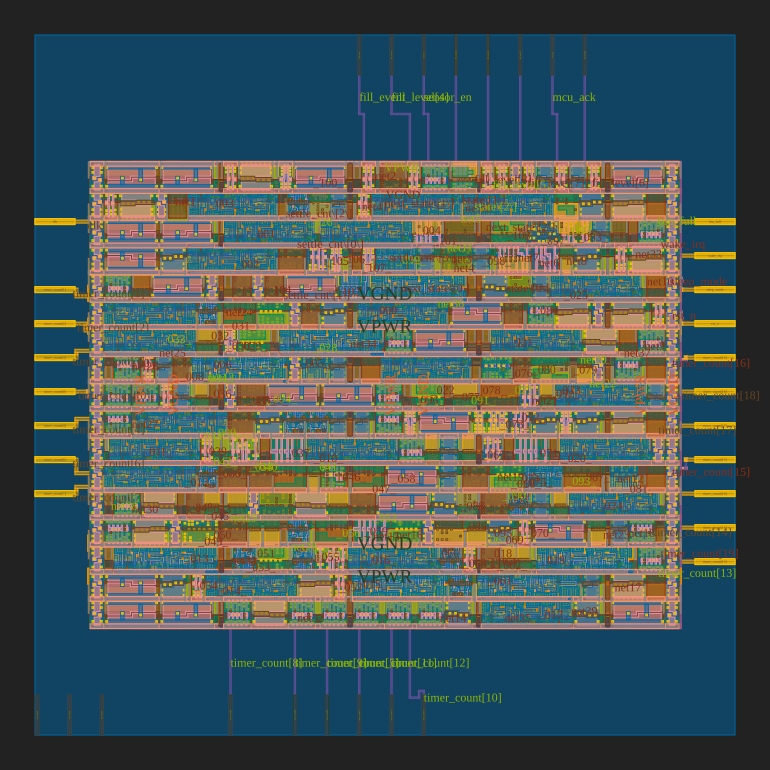

In [176]:
import pathlib
import gdstk
import IPython.display

# Actual GDS generated from our OpenLane run
gds_path = pathlib.Path(
    "runs/RUN_2026.09.25_15.15.01/results/signoff/waste_bin_wakeup.gds"
)

# Read GDS
library = gdstk.read_gds(gds_path)

# Get top-level cell
top_cells = library.top_level()

print("Top-level cells:")
for cell in top_cells:
    print(" -", cell.name)

# Generate SVG
top_cells[0].write_svg("waste_bin_wakeup_layout.svg")

# Display layout
IPython.display.SVG("waste_bin_wakeup_layout.svg")

## Metrics

[Documentation](https://openlane.readthedocs.io/en/latest/reference/datapoint_definitions.html)


In [ ]:
import pandas as pd
import pathlib

pd.options.display.max_rows = None
reports = sorted(pathlib.Path('runs').glob('*/reports/metrics.csv'))
df = pd.read_csv(reports[-1])
df.transpose()